# Diabetes prediction

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [3]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [4]:
x = df_encoded.drop(columns=["diabetes"])
y = df_encoded["diabetes"]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
   x, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [9]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[18182   110]
 [ 1641    67]]
LogisticRegression()  modeli eğitiliyor!..


C:\Users\CASPER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[18121   171]
 [  726   982]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[17779   513]
 [  443  1265]]
RandomForestClassifier()  modeli eğitiliyor!..
[[18228    64]
 [  533  1175]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[18280    12]
 [  536  1172]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[18180   112]
 [  801   907]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[18292     0]
 [  557  1151]]
MultinomialNB()  modeli eğitiliyor!..
[[17545   747]
 [ 1249   459]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[18280    12]
 [  536  1172]]
classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18292
           1       0.99      0.69      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000

Diğer Modeller:


,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.97260,0.97260,0.97260,0.97260
AdaBoostClassifier,0.97215,0.97215,0.97215,0.97215
RandomForestClassifier,0.97015,0.97015,0.97015,0.97015
LogisticRegression,0.95515,0.95515,0.95515,0.95515
KNeighborsClassifier,0.95435,0.95435,0.95435,0.95435
DecisionTreeClassifier,0.95220,0.95220,0.95220,0.95220
BernoulliNB,0.91245,0.91245,0.91245,0.91245
MultinomialNB,0.90020,0.90020,0.90020,0.90020


In [10]:
model = GradientBoostingClassifier(random_state=42)
model.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [12]:
y_pred = model.predict(x_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9726


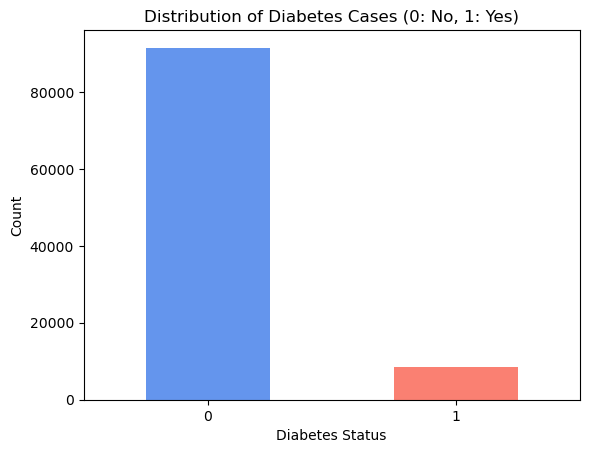

In [13]:
df["diabetes"].value_counts().plot(
    kind="bar", color=["cornflowerblue", "salmon"]
)
plt.title("Distribution of Diabetes Cases (0: No, 1: Yes)")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [14]:
joblib.dump(model, "diabetes_model.pkl")

['diabetes_model.pkl']